# Machine Learning Zoomcamp - Chapter 8: Deep Learning Homework

## Hair Type Classification using PyTorch

Dataset: Binary classification of hair types (straight vs curly)

**Requirements:**
- Image size: 200x200x3
- Batch size: 20
- Seeds: numpy=42, torch=42
- Training: 10 epochs without augmentation + 10 epochs with augmentation

## 1. Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import requests
import zipfile
import os
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Check PyTorch version and device
print(f"PyTorch version: {torch.__version__}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.9.0
Using device: cpu


## Question 1: Loss Function

**What is the appropriate loss function for binary classification?**

Options:
- mean squared error
- binary crossentropy
- categorical crossentropy
- cosine similarity

In [2]:
# Answer Q1
print("Q1 Answer: binary crossentropy")
print("\nIn PyTorch, we use:")
print("- nn.BCELoss() if model outputs sigmoid activation")
print("- nn.BCEWithLogitsLoss() if model outputs raw logits (more numerically stable)")
print("\nWe'll use nn.BCELoss() since our model will have sigmoid activation.")

Q1 Answer: binary crossentropy

In PyTorch, we use:
- nn.BCELoss() if model outputs sigmoid activation
- nn.BCEWithLogitsLoss() if model outputs raw logits (more numerically stable)

We'll use nn.BCELoss() since our model will have sigmoid activation.


## 2. Download and Extract Dataset

In [3]:
# Download dataset using requests
url = 'https://github.com/SVizor42/ML_Zoomcamp/releases/download/straight-curly-data/data.zip'
data_dir = Path('./data')
zip_path = data_dir / 'data.zip'

# Create data directory if it doesn't exist
data_dir.mkdir(exist_ok=True)

# Download the file
if not zip_path.exists():
    print("Downloading dataset...")
    response = requests.get(url, stream=True)
    total_size = int(response.headers.get('content-length', 0))
    
    with open(zip_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True, desc='Downloading') as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))
    print("Download complete!")
else:
    print("Dataset already downloaded.")

# Extract the zip file
if not (data_dir / 'data').exists():
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete!")
else:
    print("Dataset already extracted.")

Downloading:   0%|          | 0.00/103M [00:00<?, ?B/s]

Downloading:   7%|▋         | 6.79M/103M [00:00<00:01, 67.9MB/s]

Downloading:  13%|█▎        | 13.6M/103M [00:00<00:02, 31.9MB/s]

Downloading:  19%|█▊        | 19.0M/103M [00:00<00:02, 32.3MB/s]

Downloading:  22%|██▏       | 22.8M/103M [00:00<00:02, 27.4MB/s]

...

Downloading:  91%|█████████▏| 93.7M/103M [00:03<00:00, 32.6MB/s]

Downloading:  95%|█████████▌| 97.7M/103M [00:03<00:00, 27.4MB/s]

Downloading: 100%|██████████| 103M/103M [00:03<00:00, 25.9MB/s] 

Download complete!
Extracting dataset...


Extraction complete!


## 3. Explore Dataset Structure

In [4]:
# Explore dataset structure
dataset_path = data_dir / 'data'
train_path = dataset_path / 'train'
test_path = dataset_path / 'test'

print(f"Dataset path: {dataset_path}")
print(f"Train path: {train_path}")
print(f"Test path: {test_path}")

# Count images
if train_path.exists():
    classes = [d.name for d in train_path.iterdir() if d.is_dir()]
    print(f"\nClasses found: {classes}")
    
    for split in ['train', 'test']:
        split_path = dataset_path / split
        if split_path.exists():
            print(f"\n{split.upper()}:")
            for class_name in classes:
                class_path = split_path / class_name
                if class_path.exists():
                    num_images = len(list(class_path.glob('*')))
                    print(f"  {class_name}: {num_images} images")

Dataset path: data/data
Train path: data/data/train
Test path: data/data/test

Classes found: ['straight', 'curly']

TRAIN:
  straight: 390 images
  curly: 411 images

TEST:
  straight: 98 images
  curly: 103 images


## 4. Data Preparation - Without Augmentation

In [5]:
# Define transforms without augmentation
# Note: ToTensor() automatically scales pixel values to [0, 1] (equivalent to rescale=1./255)
transform_no_aug = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),  # Converts to tensor and scales to [0, 1]
])

# Load datasets
train_dataset = datasets.ImageFolder(train_path, transform=transform_no_aug)
test_dataset = datasets.ImageFolder(test_path, transform=transform_no_aug)

# Create data loaders
batch_size = 20
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Classes: {train_dataset.classes}")
print(f"Class to index: {train_dataset.class_to_idx}")

Training samples: 800
Test samples: 201
Batch size: 20
Train batches: 40
Test batches: 11
Classes: ['curly', 'straight']
Class to index: {'curly': 0, 'straight': 1}


## 5. Build CNN Model

In [6]:
class HairClassifier(nn.Module):
    def __init__(self):
        super(HairClassifier, self).__init__()
        
        # Conv2D layer: 32 filters, (3,3) kernel, ReLU activation
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=0)
        self.relu1 = nn.ReLU()
        
        # MaxPooling2D: (2,2) pooling size
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Calculate the size after conv and pooling
        # Input: 200x200
        # After conv (kernel=3, no padding): 198x198
        # After pooling (2x2): 99x99
        # Number of features: 32 * 99 * 99
        self.flatten_size = 32 * 99 * 99
        
        # Dense layer: 64 neurons, ReLU activation
        self.fc1 = nn.Linear(self.flatten_size, 64)
        self.relu2 = nn.ReLU()
        
        # Dense output layer: 1 neuron with sigmoid activation
        self.fc2 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        # Conv + ReLU
        x = self.conv1(x)
        x = self.relu1(x)
        
        # MaxPooling
        x = self.pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dense + ReLU
        x = self.fc1(x)
        x = self.relu2(x)
        
        # Output + Sigmoid
        x = self.fc2(x)
        x = self.sigmoid(x)
        
        return x

# Create model and move to device
model = HairClassifier().to(device)
print(model)

HairClassifier(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
  (relu1): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=313632, out_features=64, bias=True)
  (relu2): ReLU()
  (fc2): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


## Question 2: Model Parameters

**What is the total number of parameters in the model?**

Options:
- 896
- 11,214,912
- 15,896,912
- 20,072,512

In [7]:
# Count model parameters
def count_parameters(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)

print("Model Parameters Breakdown:")
print("=" * 60)
for name, param in model.named_parameters():
    print(f"{name:20s} | Shape: {str(param.shape):20s} | Params: {param.numel():,}")
print("=" * 60)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print(f"\n✓ Q2 Answer: {total_params:,}")

Model Parameters Breakdown:
conv1.weight         | Shape: torch.Size([32, 3, 3, 3]) | Params: 864
conv1.bias           | Shape: torch.Size([32])     | Params: 32
fc1.weight           | Shape: torch.Size([64, 313632]) | Params: 20,072,448
fc1.bias             | Shape: torch.Size([64])     | Params: 64
fc2.weight           | Shape: torch.Size([1, 64])  | Params: 64
fc2.bias             | Shape: torch.Size([1])      | Params: 1
Total parameters: 20,073,473
Trainable parameters: 20,073,473

✓ Q2 Answer: 20,073,473


## 6. Configure Training

In [8]:
# Optimizer: SGD with lr=0.002, momentum=0.8
optimizer = optim.SGD(model.parameters(), lr=0.002, momentum=0.8)

# Loss function: Binary Cross Entropy
criterion = nn.BCELoss()

print("Training configuration:")
print(f"Optimizer: SGD(lr=0.002, momentum=0.8)")
print(f"Loss function: BCELoss")
print(f"Device: {device}")

Training configuration:
Optimizer: SGD(lr=0.002, momentum=0.8)
Loss function: BCELoss
Device: cpu


## 7. Training Functions

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.float().unsqueeze(1).to(device)  # Convert to float and add dimension
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item() * images.size(0)
        predicted = (outputs > 0.5).float()
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.float().unsqueeze(1).to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


## 8. Train Without Augmentation (10 epochs)

In [10]:
# Training without augmentation
num_epochs = 10

history_no_aug = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Training without augmentation...")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    
    history_no_aug['train_loss'].append(train_loss)
    history_no_aug['train_acc'].append(train_acc)
    history_no_aug['test_loss'].append(test_loss)
    history_no_aug['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 70)

print("Training without augmentation completed!")

Training without augmentation...


Epoch 1/10:
  Train Loss: 0.6643 | Train Acc: 0.5875
  Test Loss:  0.7355 | Test Acc:  0.5572
----------------------------------------------------------------------


Epoch 2/10:
  Train Loss: 0.6017 | Train Acc: 0.6488
  Test Loss:  0.6298 | Test Acc:  0.6219
----------------------------------------------------------------------


Epoch 3/10:
  Train Loss: 0.6103 | Train Acc: 0.6687
  Test Loss:  0.6295 | Test Acc:  0.6219
----------------------------------------------------------------------


Epoch 4/10:
  Train Loss: 0.5629 | Train Acc: 0.6987
  Test Loss:  0.6172 | Test Acc:  0.6368
----------------------------------------------------------------------


...

Epoch 6/10:
  Train Loss: 0.5197 | Train Acc: 0.7400
  Test Loss:  0.6003 | Test Acc:  0.6667
----------------------------------------------------------------------


Epoch 7/10:
  Train Loss: 0.5038 | Train Acc: 0.7438
  Test Loss:  0.6075 | Test Acc:  0.6517
----------------------------------------------------------------------


Epoch 8/10:
  Train Loss: 0.5002 | Train Acc: 0.7512
  Test Loss:  0.5908 | Test Acc:  0.6816
----------------------------------------------------------------------


Epoch 9/10:
  Train Loss: 0.4725 | Train Acc: 0.7762
  Test Loss:  0.6018 | Test Acc:  0.6667
----------------------------------------------------------------------


Epoch 10/10:
  Train Loss: 0.4423 | Train Acc: 0.7837
  Test Loss:  0.5889 | Test Acc:  0.6816
----------------------------------------------------------------------
Training without augmentation completed!


## Question 3: Median Training Accuracy

**What is the median training accuracy across all 10 epochs?**

Options:
- 0.10
- 0.32
- 0.50
- 0.72

In [11]:
# Calculate median training accuracy
train_accuracies = np.array(history_no_aug['train_acc'])
median_train_acc = np.median(train_accuracies)

print("Training accuracies per epoch:")
for i, acc in enumerate(train_accuracies):
    print(f"  Epoch {i+1}: {acc:.4f}")

print(f"\n✓ Q3 Answer - Median training accuracy: {median_train_acc:.2f}")

Training accuracies per epoch:
  Epoch 1: 0.5875
  Epoch 2: 0.6488
  Epoch 3: 0.6687
  Epoch 4: 0.6987
  Epoch 5: 0.7137
  Epoch 6: 0.7400
  Epoch 7: 0.7438
  Epoch 8: 0.7512
  Epoch 9: 0.7762
  Epoch 10: 0.7837

✓ Q3 Answer - Median training accuracy: 0.73


## Question 4: Standard Deviation of Training Loss

**What is the standard deviation of training loss across all 10 epochs?**

Options:
- 0.028
- 0.068
- 0.128
- 0.168

In [12]:
# Calculate standard deviation of training loss
train_losses = np.array(history_no_aug['train_loss'])
std_train_loss = np.std(train_losses)

print("Training losses per epoch:")
for i, loss in enumerate(train_losses):
    print(f"  Epoch {i+1}: {loss:.4f}")

print(f"\nMean: {np.mean(train_losses):.4f}")
print(f"\n✓ Q4 Answer - Standard deviation of training loss: {std_train_loss:.3f}")

Training losses per epoch:
  Epoch 1: 0.6643
  Epoch 2: 0.6017
  Epoch 3: 0.6103
  Epoch 4: 0.5629
  Epoch 5: 0.5673
  Epoch 6: 0.5197
  Epoch 7: 0.5038
  Epoch 8: 0.5002
  Epoch 9: 0.4725
  Epoch 10: 0.4423

Mean: 0.5445

✓ Q4 Answer - Standard deviation of training loss: 0.065


## 9. Visualize Training Progress (Without Augmentation)

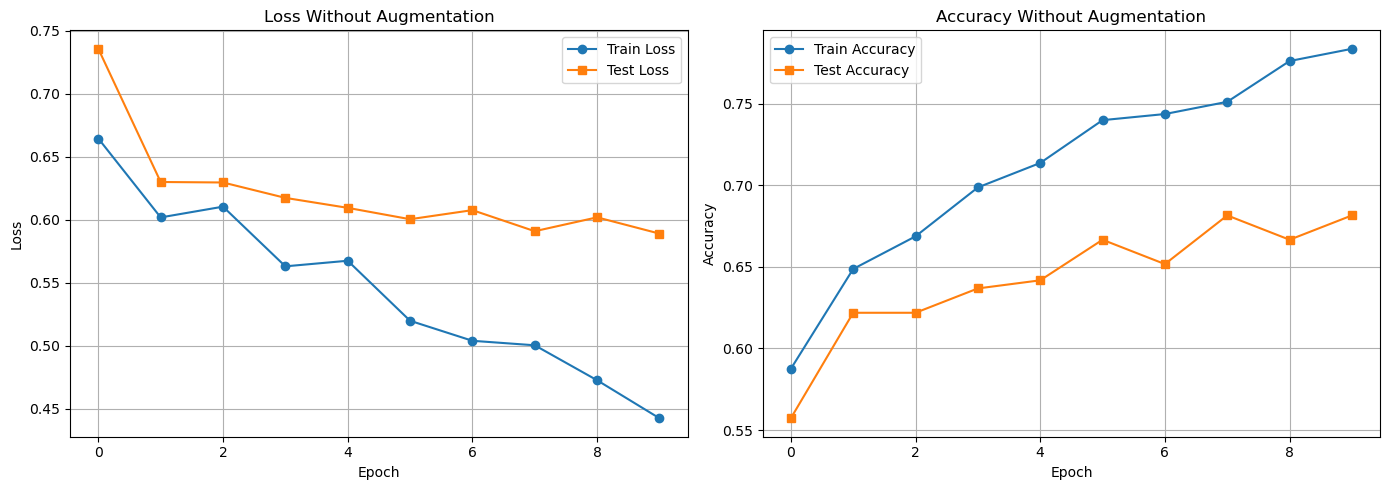

In [13]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history_no_aug['train_loss'], label='Train Loss', marker='o')
ax1.plot(history_no_aug['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Without Augmentation')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(history_no_aug['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history_no_aug['test_acc'], label='Test Accuracy', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy Without Augmentation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 10. Data Augmentation Setup

In [14]:
# Define transforms WITH augmentation for training
transform_with_aug = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomRotation(degrees=50),  # rotation_range=50
    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1),  # width_shift_range=0.1, height_shift_range=0.1
    ),
    transforms.RandomResizedCrop(
        size=200,
        scale=(0.9, 1.0),  # zoom_range=0.1 (90% to 100%)
        ratio=(1.0, 1.0)   # keep aspect ratio
    ),
    transforms.RandomHorizontalFlip(p=0.5),  # horizontal_flip=True
    transforms.ToTensor(),
])

# Test set keeps the same transform (no augmentation)
transform_test = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.ToTensor(),
])

# Create new datasets with augmentation
train_dataset_aug = datasets.ImageFolder(train_path, transform=transform_with_aug)
test_dataset_aug = datasets.ImageFolder(test_path, transform=transform_test)

# Create new data loaders
train_loader_aug = DataLoader(train_dataset_aug, batch_size=batch_size, shuffle=True)
test_loader_aug = DataLoader(test_dataset_aug, batch_size=batch_size, shuffle=False)

print("Data augmentation configured:")
print("  - Random rotation: ±50 degrees")
print("  - Random translation: ±10% width and height")
print("  - Random zoom: 90-100% scale")
print("  - Random horizontal flip: 50% probability")
print(f"\nTraining batches with augmentation: {len(train_loader_aug)}")
print(f"Test batches: {len(test_loader_aug)}")

Data augmentation configured:
  - Random rotation: ±50 degrees
  - Random translation: ±10% width and height
  - Random zoom: 90-100% scale
  - Random horizontal flip: 50% probability

Training batches with augmentation: 40
Test batches: 11


## 11. Reset and Train With Augmentation (10 epochs)

In [15]:
# Reset model for training with augmentation
model_aug = HairClassifier().to(device)
optimizer_aug = optim.SGD(model_aug.parameters(), lr=0.002, momentum=0.8)

# Training with augmentation
history_with_aug = {
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': []
}

print("Training WITH augmentation...")
print("=" * 70)

for epoch in range(num_epochs):
    train_loss, train_acc = train_epoch(model_aug, train_loader_aug, criterion, optimizer_aug, device)
    test_loss, test_acc = evaluate(model_aug, test_loader_aug, criterion, device)
    
    history_with_aug['train_loss'].append(train_loss)
    history_with_aug['train_acc'].append(train_acc)
    history_with_aug['test_loss'].append(test_loss)
    history_with_aug['test_acc'].append(test_acc)
    
    print(f"Epoch {epoch+1}/{num_epochs}:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 70)

print("Training with augmentation completed!")

Training WITH augmentation...


Epoch 1/10:
  Train Loss: 0.6974 | Train Acc: 0.5062
  Test Loss:  0.6895 | Test Acc:  0.4975
----------------------------------------------------------------------


Epoch 2/10:
  Train Loss: 0.6923 | Train Acc: 0.5450
  Test Loss:  0.6883 | Test Acc:  0.4876
----------------------------------------------------------------------


Epoch 3/10:
  Train Loss: 0.6890 | Train Acc: 0.5587
  Test Loss:  0.6854 | Test Acc:  0.6219
----------------------------------------------------------------------


Epoch 4/10:
  Train Loss: 0.6852 | Train Acc: 0.5725
  Test Loss:  0.6887 | Test Acc:  0.5423
----------------------------------------------------------------------


...

Epoch 6/10:
  Train Loss: 0.6731 | Train Acc: 0.5875
  Test Loss:  0.6389 | Test Acc:  0.6418
----------------------------------------------------------------------


Epoch 7/10:
  Train Loss: 0.6572 | Train Acc: 0.6125
  Test Loss:  0.6451 | Test Acc:  0.6119
----------------------------------------------------------------------


Epoch 8/10:
  Train Loss: 0.6413 | Train Acc: 0.6300
  Test Loss:  0.6214 | Test Acc:  0.6169
----------------------------------------------------------------------


Epoch 9/10:
  Train Loss: 0.6519 | Train Acc: 0.6350
  Test Loss:  0.6288 | Test Acc:  0.5970
----------------------------------------------------------------------


Epoch 10/10:
  Train Loss: 0.6453 | Train Acc: 0.6200
  Test Loss:  0.6184 | Test Acc:  0.6567
----------------------------------------------------------------------
Training with augmentation completed!


## Question 5: Mean Test Loss with Augmentation

**What is the mean test loss after adding data augmentation?**

Options:
- 0.26
- 0.56
- 0.86
- 1.16

In [16]:
# Calculate mean test loss with augmentation
test_losses_aug = np.array(history_with_aug['test_loss'])
mean_test_loss = np.mean(test_losses_aug)

print("Test losses per epoch (with augmentation):")
for i, loss in enumerate(test_losses_aug):
    print(f"  Epoch {i+1}: {loss:.4f}")

print(f"\n✓ Q5 Answer - Mean test loss with augmentation: {mean_test_loss:.2f}")

Test losses per epoch (with augmentation):
  Epoch 1: 0.6895
  Epoch 2: 0.6883
  Epoch 3: 0.6854
  Epoch 4: 0.6887
  Epoch 5: 0.6605
  Epoch 6: 0.6389
  Epoch 7: 0.6451
  Epoch 8: 0.6214
  Epoch 9: 0.6288
  Epoch 10: 0.6184

✓ Q5 Answer - Mean test loss with augmentation: 0.66


## Question 6: Average Test Accuracy (Epochs 6-10)

**What is the average test accuracy for epochs 6-10 with augmentation?**

Options:
- 0.31
- 0.51
- 0.71
- 0.91

In [17]:
# Calculate average test accuracy for epochs 6-10
test_accuracies_aug = np.array(history_with_aug['test_acc'])
avg_test_acc_6_10 = np.mean(test_accuracies_aug[5:10])  # epochs 6-10 (indices 5-9)

print("Test accuracies per epoch (with augmentation):")
for i, acc in enumerate(test_accuracies_aug):
    marker = " <--" if i >= 5 else ""
    print(f"  Epoch {i+1}: {acc:.4f}{marker}")

print(f"\nEpochs 6-10: {test_accuracies_aug[5:10]}")
print(f"\n✓ Q6 Answer - Average test accuracy (epochs 6-10): {avg_test_acc_6_10:.2f}")

Test accuracies per epoch (with augmentation):
  Epoch 1: 0.4975
  Epoch 2: 0.4876
  Epoch 3: 0.6219
  Epoch 4: 0.5423
  Epoch 5: 0.6169
  Epoch 6: 0.6418 <--
  Epoch 7: 0.6119 <--
  Epoch 8: 0.6169 <--
  Epoch 9: 0.5970 <--
  Epoch 10: 0.6567 <--

Epochs 6-10: [0.64179104 0.6119403  0.61691542 0.59701493 0.65671642]

✓ Q6 Answer - Average test accuracy (epochs 6-10): 0.62


## 12. Visualize Training Progress (With Augmentation)

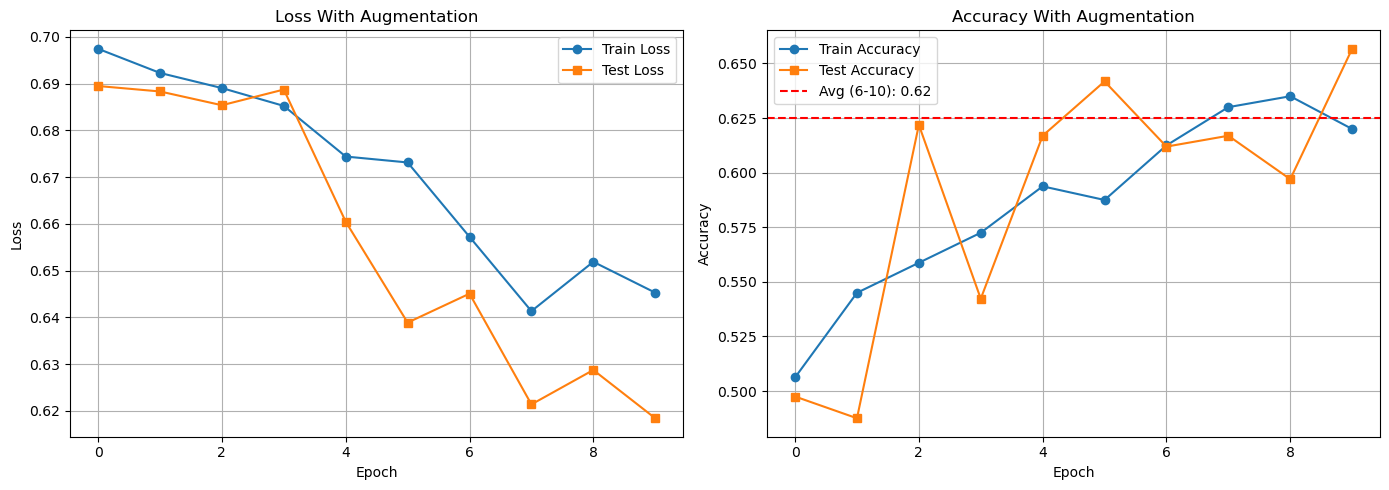

In [18]:
# Plot training history with augmentation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(history_with_aug['train_loss'], label='Train Loss', marker='o')
ax1.plot(history_with_aug['test_loss'], label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss With Augmentation')
ax1.legend()
ax1.grid(True)

# Plot accuracy
ax2.plot(history_with_aug['train_acc'], label='Train Accuracy', marker='o')
ax2.plot(history_with_aug['test_acc'], label='Test Accuracy', marker='s')
ax2.axhline(y=avg_test_acc_6_10, color='r', linestyle='--', label=f'Avg (6-10): {avg_test_acc_6_10:.2f}')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy With Augmentation')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 13. Summary of Answers

In [19]:
print("="*70)
print("HOMEWORK ANSWERS SUMMARY")
print("="*70)
print(f"Q1 - Loss function: binary crossentropy (nn.BCELoss in PyTorch)")
print(f"Q2 - Total parameters: {total_params:,}")
print(f"Q3 - Median training accuracy: {median_train_acc:.2f}")
print(f"Q4 - Std of training loss: {std_train_loss:.3f}")
print(f"Q5 - Mean test loss (with aug): {mean_test_loss:.2f}")
print(f"Q6 - Avg test accuracy epochs 6-10: {avg_test_acc_6_10:.2f}")
print("="*70)

HOMEWORK ANSWERS SUMMARY
Q1 - Loss function: binary crossentropy (nn.BCELoss in PyTorch)
Q2 - Total parameters: 20,073,473
Q3 - Median training accuracy: 0.73
Q4 - Std of training loss: 0.065
Q5 - Mean test loss (with aug): 0.66
Q6 - Avg test accuracy epochs 6-10: 0.62


## 14. Comparison: With vs Without Augmentation

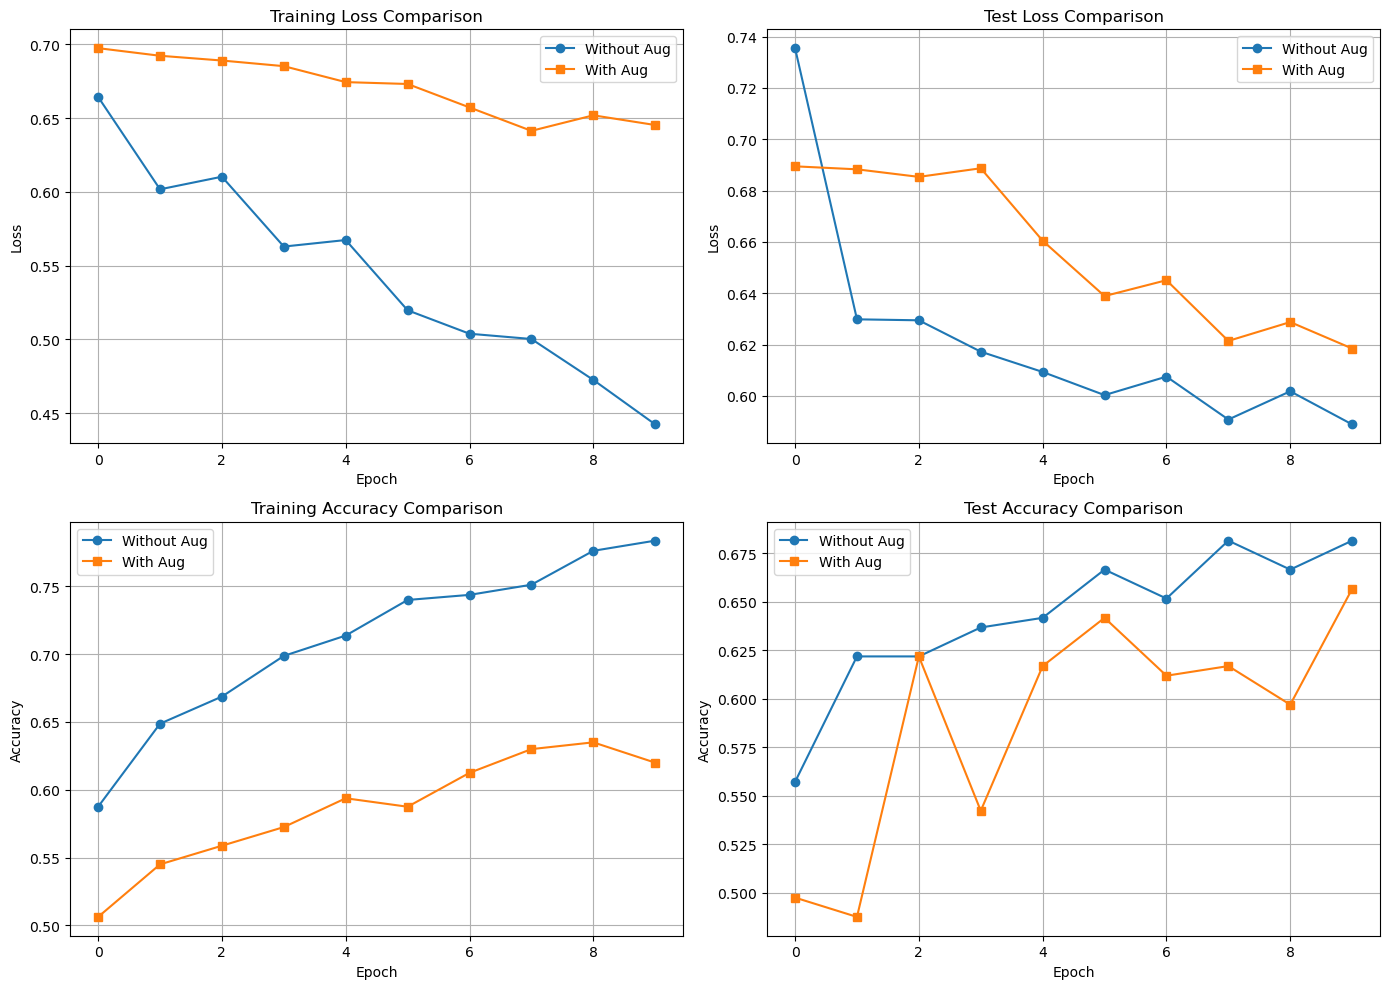


Final Results:

Without Augmentation:
  Final Train Acc: 0.7837
  Final Test Acc:  0.6816
  Final Train Loss: 0.4423
  Final Test Loss:  0.5889

With Augmentation:
  Final Train Acc: 0.6200
  Final Test Acc:  0.6567
  Final Train Loss: 0.6453
  Final Test Loss:  0.6184


In [20]:
# Compare results
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Train Loss
ax1.plot(history_no_aug['train_loss'], label='Without Aug', marker='o')
ax1.plot(history_with_aug['train_loss'], label='With Aug', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True)

# Test Loss
ax2.plot(history_no_aug['test_loss'], label='Without Aug', marker='o')
ax2.plot(history_with_aug['test_loss'], label='With Aug', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Test Loss Comparison')
ax2.legend()
ax2.grid(True)

# Train Accuracy
ax3.plot(history_no_aug['train_acc'], label='Without Aug', marker='o')
ax3.plot(history_with_aug['train_acc'], label='With Aug', marker='s')
ax3.set_xlabel('Epoch')
ax3.set_ylabel('Accuracy')
ax3.set_title('Training Accuracy Comparison')
ax3.legend()
ax3.grid(True)

# Test Accuracy
ax4.plot(history_no_aug['test_acc'], label='Without Aug', marker='o')
ax4.plot(history_with_aug['test_acc'], label='With Aug', marker='s')
ax4.set_xlabel('Epoch')
ax4.set_ylabel('Accuracy')
ax4.set_title('Test Accuracy Comparison')
ax4.legend()
ax4.grid(True)

plt.tight_layout()
plt.show()

print("\nFinal Results:")
print("\nWithout Augmentation:")
print(f"  Final Train Acc: {history_no_aug['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:  {history_no_aug['test_acc'][-1]:.4f}")
print(f"  Final Train Loss: {history_no_aug['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {history_no_aug['test_loss'][-1]:.4f}")

print("\nWith Augmentation:")
print(f"  Final Train Acc: {history_with_aug['train_acc'][-1]:.4f}")
print(f"  Final Test Acc:  {history_with_aug['test_acc'][-1]:.4f}")
print(f"  Final Train Loss: {history_with_aug['train_loss'][-1]:.4f}")
print(f"  Final Test Loss:  {history_with_aug['test_loss'][-1]:.4f}")